# Exploratory Data Analysis: Aggregated Electricity Prices
This notebook performs basic pre-processing, shows statistics, and visualizes insights from the aggregated daily electricity prices dataset.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Load the data
file_path = '../Data/preprocessed/aggregated_prices.csv'
df = pd.read_csv(file_path, parse_dates=['Time'], index_col='Time')

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (76663, 39)


,HR,SE,GR,IT,PL,SE.1,FR,IE,HU,RS,...,NL,ME,BE,SE.2,CH,MK,CZ,IT.1,AT,SE.3
Time,,,,,,,,,,,,,,,,,,,,,
2018-01-01 00:00:00+00:00,15.50,26.43,57.96,44.16,116.37,26.43,4.74,55.08,0.22,0.0,...,27.30,NaN,4.74,26.43,31.08,NaN,-19.0,44.16,NaN,26.43
2018-01-01 01:00:00+00:00,14.25,26.10,54.58,42.24,109.94,26.10,3.66,39.38,0.21,0.0,...,30.10,NaN,3.66,26.10,29.17,NaN,-20.1,42.24,NaN,26.10
2018-01-01 02:00:00+00:00,12.95,24.70,54.47,39.29,104.06,24.70,1.26,38.56,0.07,0.0,...,20.87,NaN,1.26,24.70,21.96,NaN,-26.9,39.29,NaN,24.70
2018-01-01 03:00:00+00:00,9.15,24.74,54.85,36.00,104.24,24.74,-20.10,38.56,-17.44,0.0,...,25.56,NaN,-20.10,24.74,14.96,NaN,-27.5,36.00,NaN,24.74
2018-01-01 04:00:00+00:00,10.45,18.01,54.85,41.99,75.88,18.01,-31.82,38.24,-25.97,0.0,...,25.58,NaN,-31.82,18.01,-5.92,NaN,-34.0,41.99,NaN,18.01


## Basic Statistics & Pre-processing
Checking for missing values and overall summary statistics.

In [4]:
# Check missing values
missing_data = df.isna().mean() * 100
print("Percentage of missing values per country:")
print(missing_data[missing_data > 0].sort_values(ascending=False).head())

# Basic statistics
display(df.describe())

Percentage of missing values per country:
DE.1    91.456113
MK      69.817252
ME      69.347664
IE       8.779985
CH       8.554322
dtype: float64


,HR,SE,GR,IT,PL,SE.1,FR,IE,HU,RS,...,NL,ME,BE,SE.2,CH,MK,CZ,IT.1,AT,SE.3
count,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,69932.000000,76663.000000,76663.000000,...,76663.000000,23499.000000,76663.000000,76663.000000,70105.000000,23139.000000,76663.000000,76663.000000,70113.000000,76663.000000
mean,104.708107,64.999118,111.010186,112.813764,129.561783,54.231863,87.862128,107.131079,106.573246,106.314120,...,91.027492,103.773947,89.907581,34.278056,101.072624,103.446830,94.743339,118.898985,102.949558,34.085652
std,93.072730,71.430161,89.465336,90.890766,79.548358,63.534012,96.138987,81.413206,95.817993,92.627826,...,84.592469,43.471738,85.862479,38.694374,95.468339,58.581908,86.834353,91.041663,92.618851,37.973205
min,-500.000000,-60.040000,-50.000000,0.000000,-132.950000,-60.040000,-134.940000,-79.010000,-500.000000,0.000000,...,-500.000000,0.000000,-500.000000,-60.040000,-427.510000,0.000000,-224.490000,0.000000,-500.000000,-94.590000
25%,47.230000,27.025000,59.150000,54.860000,74.340000,21.160000,35.010000,50.580000,47.620000,48.010000,...,41.040000,81.670000,40.215000,9.480000,43.030000,75.435000,41.880000,61.120000,44.620000,9.900000
50%,80.970000,45.650000,83.390000,97.000000,108.770000,39.180000,58.970000,88.000000,81.820000,81.090000,...,70.750000,102.930000,68.490000,28.690000,71.640000,99.400000,74.820000,102.970000,84.070000,28.430000
75%,125.400000,79.150000,131.160000,132.755000,173.685000,59.930000,100.520000,135.100000,128.480000,127.900000,...,108.500000,123.195000,106.000000,45.660000,120.350000,123.395000,114.530000,136.080000,124.900000,45.445000
max,920.000000,799.970000,942.000000,871.000000,887.650000,799.970000,2987.780000,705.470000,1047.100000,899.970000,...,872.960000,1150.500000,871.000000,590.000000,871.610000,813.300000,871.000000,870.000000,919.640000,590.000000


In [8]:
# ...existing code...
# Check missing values
missing_data = df.isna().mean() * 100
print("--- Percentage of missing values per country (Top 5) ---")
print(missing_data[missing_data > 0].sort_values(ascending=False).head())

print("\n--- Summary Statistics ---")
display(df.describe())

print("\n--- Key Price Statistics ---")
# Overall average across everything
overall_avg = df.mean().mean()
print(f"Overall Average Price (All Contexts): {overall_avg:.2f} EUR/MWh")

# Volatility (Standard Deviation)
std_dev = df.std().sort_values(ascending=False)
print(f"Most Volatile Country: {std_dev.index[0]} (Std. Dev: {std_dev.iloc[0]:.2f})")
print(f"Least Volatile Country: {std_dev.index[-1]} (Std. Dev: {std_dev.iloc[-1]:.2f})")

# Extreme Values
max_price_series = df.max()
min_price_series = df.min()
highest_country = max_price_series.idxmax()
lowest_country = min_price_series.idxmin()

print(f"Highest Single Daily Price: {max_price_series.max():.2f} EUR/MWh (Recorded in {highest_country})")
print(f"Lowest Single Daily Price: {min_price_series.min():.2f} EUR/MWh (Recorded in {lowest_country})")
#

--- Percentage of missing values per country (Top 5) ---
DE.1    91.456113
MK      69.817252
ME      69.347664
IE       8.779985
CH       8.554322
dtype: float64

--- Summary Statistics ---


,HR,SE,GR,IT,PL,SE.1,FR,IE,HU,RS,...,NL,ME,BE,SE.2,CH,MK,CZ,IT.1,AT,SE.3
count,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,76663.000000,69932.000000,76663.000000,76663.000000,...,76663.000000,23499.000000,76663.000000,76663.000000,70105.000000,23139.000000,76663.000000,76663.000000,70113.000000,76663.000000
mean,104.708107,64.999118,111.010186,112.813764,129.561783,54.231863,87.862128,107.131079,106.573246,106.314120,...,91.027492,103.773947,89.907581,34.278056,101.072624,103.446830,94.743339,118.898985,102.949558,34.085652
std,93.072730,71.430161,89.465336,90.890766,79.548358,63.534012,96.138987,81.413206,95.817993,92.627826,...,84.592469,43.471738,85.862479,38.694374,95.468339,58.581908,86.834353,91.041663,92.618851,37.973205
min,-500.000000,-60.040000,-50.000000,0.000000,-132.950000,-60.040000,-134.940000,-79.010000,-500.000000,0.000000,...,-500.000000,0.000000,-500.000000,-60.040000,-427.510000,0.000000,-224.490000,0.000000,-500.000000,-94.590000
25%,47.230000,27.025000,59.150000,54.860000,74.340000,21.160000,35.010000,50.580000,47.620000,48.010000,...,41.040000,81.670000,40.215000,9.480000,43.030000,75.435000,41.880000,61.120000,44.620000,9.900000
50%,80.970000,45.650000,83.390000,97.000000,108.770000,39.180000,58.970000,88.000000,81.820000,81.090000,...,70.750000,102.930000,68.490000,28.690000,71.640000,99.400000,74.820000,102.970000,84.070000,28.430000
75%,125.400000,79.150000,131.160000,132.755000,173.685000,59.930000,100.520000,135.100000,128.480000,127.900000,...,108.500000,123.195000,106.000000,45.660000,120.350000,123.395000,114.530000,136.080000,124.900000,45.445000
max,920.000000,799.970000,942.000000,871.000000,887.650000,799.970000,2987.780000,705.470000,1047.100000,899.970000,...,872.960000,1150.500000,871.000000,590.000000,871.610000,813.300000,871.000000,870.000000,919.640000,590.000000



--- Key Price Statistics ---
Overall Average Price (All Contexts): 87.35 EUR/MWh
Most Volatile Country: RO (Std. Dev: 110.30)
Least Volatile Country: DE.1 (Std. Dev: 16.60)
Highest Single Daily Price: 4000.00 EUR/MWh (Recorded in LV)
Lowest Single Daily Price: -500.00 EUR/MWh (Recorded in HR)


In [10]:

print("\n--- Key Price Statistics ---")
# Overall average across everything
overall_avg = df.mean().mean()
print(f"Overall Average Price (All Contexts): {overall_avg:.2f} EUR/MWh")

# Volatility (Standard Deviation)
std_dev = df.std().sort_values(ascending=False)
avg_volatility = std_dev.mean()

print(f"\nAverage Volatility (Std. Dev) across all countries: {avg_volatility:.2f}")

print("\nTop 5 Most Volatile Countries:")
for country, vol in std_dev.head(5).items():
    print(f" - {country}: {vol:.2f}")

print(f"\nLeast Volatile Country: {std_dev.index[-1]} (Std. Dev: {std_dev.iloc[-1]:.2f})")

# Extreme Values
max_price_series = df.max()



--- Key Price Statistics ---
Overall Average Price (All Contexts): 87.35 EUR/MWh

Average Volatility (Std. Dev) across all countries: 76.12

Top 5 Most Volatile Countries:
 - RO: 110.30
 - BG: 102.36
 - FR: 96.14
 - HU: 95.82
 - CH: 95.47

Least Volatile Country: DE.1 (Std. Dev: 16.60)


## Visualizations
### 1. Price Trends Over Time
Visualizing a subset of countries to avoid clutter and identify temporal trends or price spikes.

<Figure size 1400x600 with 0 Axes>

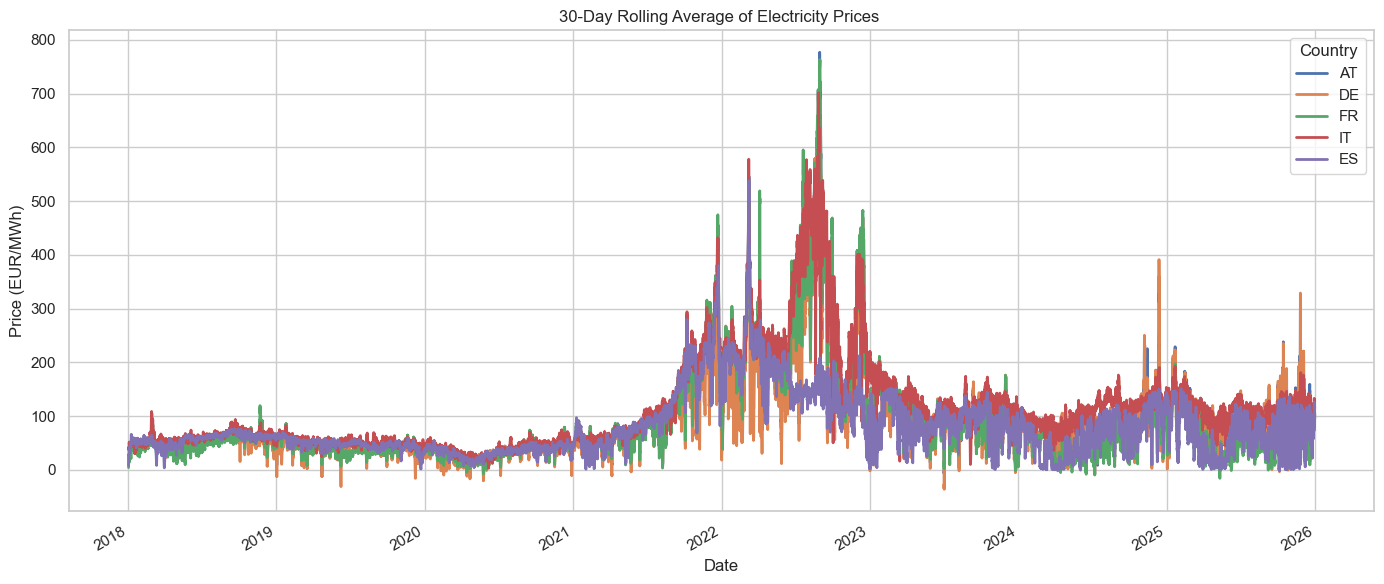

In [7]:
plt.figure(figsize=(14, 6))
# Selecting a few distinct European markets as an example
sample_countries = ['AT', 'DE', 'FR', 'IT', 'ES'] 

# Plot 30-day rolling average to smooth out daily volatility
df[sample_countries].rolling(window=30).mean().plot(figsize=(14, 6), linewidth=2)

plt.title('30-Day Rolling Average of Electricity Prices ')
plt.ylabel('Price (EUR/MWh)')
plt.xlabel('Date')
plt.legend(title='Country')
plt.tight_layout()
plt.show()

### 2. Average Price Comparison
Comparing the overall average electricity price across all available countries.

/var/folders/7j/lh0k6xxj3yn_kdygsttx8q5c0000gn/T/ipykernel_8610/2304980005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_prices.index, y=mean_prices.values, palette='viridis')


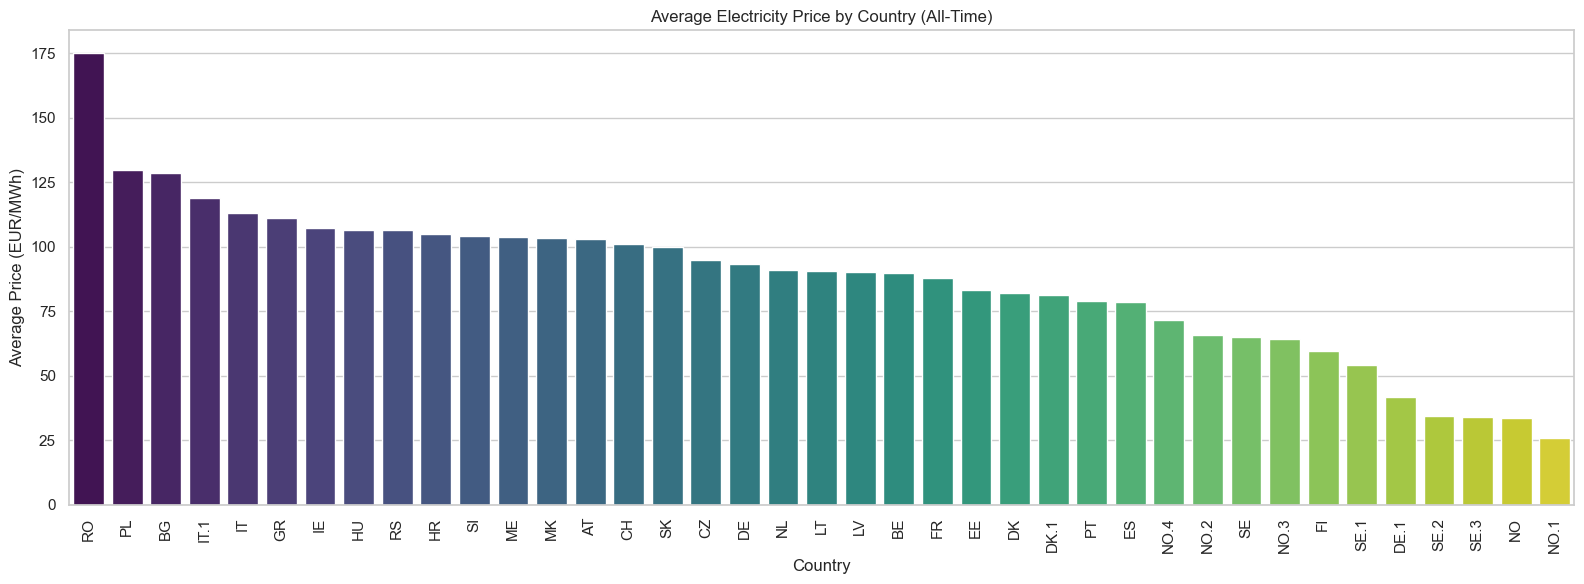

In [6]:
plt.figure(figsize=(16, 6))
mean_prices = df.mean().sort_values(ascending=False)

sns.barplot(x=mean_prices.index, y=mean_prices.values, palette='viridis')
plt.title('Average Electricity Price by Country (All-Time)')
plt.ylabel('Average Price (EUR/MWh)')
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Insights
* **Volatility**: The rolling average chart helps highlight major structural market changes (e.g., energy crises) rather than daily fluctuations.
* **Disparities**: The bar chart shows distinct tiers in energy costs, often correlated with the country's generation mix (e.g., nuclear/hydro vs gas reliance) and interconnectivity.